# CNN from Scratch — building toward self-driving object detection

This notebook is step 1 of the path laid out in `learning.md` (DPM → R-CNN → YOLO). Before any of those detectors make sense, you need to understand the thing they all have in common under the hood: a **CNN backbone** that turns an image into features.

**Goal of this notebook:** build, train, and evaluate a CNN classifier from scratch in PyTorch — no shortcuts, every layer explained. Once this is solid, the next notebook bolts a bounding-box head onto the same backbone (mini-YOLO style) so you can see exactly how classification becomes detection.

**Dataset: GTSRB (German Traffic Sign Recognition Benchmark)** — 43 classes of real traffic signs, ~50k images. It's driving-relevant (traffic-sign recognition is a real perception subtask in self-driving stacks), ships directly in `torchvision.datasets` so it auto-downloads, and it's small enough (~300MB) to train on quickly — unlike KITTI/BDD100K which are detection-labeled and much heavier to wrangle for a first pass. We'll get to full driving-scene detection datasets once the fundamentals click.

In [23]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
from tqdm.auto import tqdm
import matplotlib.pyplot as plt

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cuda


C:\Users\bangu\AppData\Roaming\Python\Python314\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 1. Load the data

Images come in all sizes in GTSRB, so we resize everything to a fixed 32x32 — CNNs need a fixed input size because the fully-connected layers at the end expect a fixed number of features.

We also normalize pixel values to roughly [-1, 1]. This isn't cosmetic: gradients flow much better through the network when inputs aren't all large positive numbers (0-255).

In [24]:
IMG_SIZE = 32

transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),                       # HWC [0,255] -> CHW [0,1]
    transforms.Normalize(mean=[0.5, 0.5, 0.5],
                          std=[0.5, 0.5, 0.5]),   # -> roughly [-1, 1]
])

train_set = datasets.GTSRB(root="./data", split="train", download=True, transform=transform)
test_set  = datasets.GTSRB(root="./data", split="test",  download=True, transform=transform)

train_loader = DataLoader(train_set, batch_size=64, shuffle=True, num_workers=0)
test_loader  = DataLoader(test_set,  batch_size=64, shuffle=False, num_workers=0)

NUM_CLASSES = 43
print(f"train images: {len(train_set)}, test images: {len(test_set)}")

train images: 26640, test images: 12630


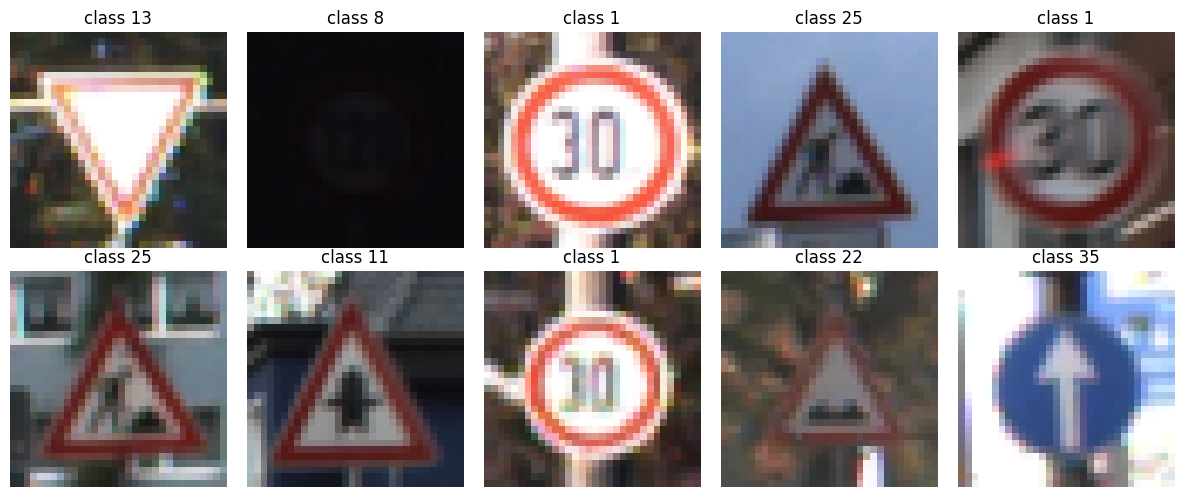

In [25]:
# Sanity check: look at a batch before trusting anything downstream
def unnormalize(img_tensor):
    return img_tensor * 0.5 + 0.5  # undo the Normalize() above, back to [0,1]

images, labels = next(iter(train_loader))

fig, axes = plt.subplots(2, 5, figsize=(12, 5))
for i, ax in enumerate(axes.flat):
    img = unnormalize(images[i]).permute(1, 2, 0)  # CHW -> HWC for matplotlib
    ax.imshow(img)
    ax.set_title(f"class {labels[i].item()}")
    ax.axis("off")
plt.tight_layout()
plt.show()

## 2. The CNN building blocks

A CNN classifier is really just a feature extractor followed by a classifier:

- **Conv2d** — slides a small learnable filter (e.g. 3x3) across the image. Each filter learns to detect one kind of local pattern (an edge, a corner, a color blob). Early layers learn simple patterns; deeper layers combine them into complex ones (shapes, then whole sign faces). This is the *same* operation R-CNN and YOLO use to extract features from images.
- **ReLU** — `max(0, x)`. Without a nonlinearity, stacking conv layers would collapse into one big linear operation, no matter how many layers you stack. ReLU is what lets depth actually buy you more representational power.
- **MaxPool2d** — shrinks the feature map (e.g. 2x2 -> takes the max), which (a) reduces compute for later layers and (b) gives a little translation invariance — a sign shifted a few pixels still activates roughly the same pooled feature.
- **Flatten + Linear** — once we've extracted spatial features, we flatten them into a vector and feed a normal fully-connected layer to produce class scores (logits). This last part is what changes when you go from *classification* to *detection*: instead of one class score per image, a detector predicts a grid of boxes + classes. Same backbone, different head.

In [26]:
class TrafficSignCNN(nn.Module):
    def __init__(self, num_classes=NUM_CLASSES):
        super().__init__()
        # Block 1: 3 -> 32 channels, 32x32 -> 16x16
        self.conv1 = nn.Conv2d(3, 32, kernel_size=3, padding=1)
        self.bn1   = nn.BatchNorm2d(32)

        # Block 2: 32 -> 64 channels, 16x16 -> 8x8
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, padding=1)
        self.bn2   = nn.BatchNorm2d(64)

        # Block 3: 64 -> 128 channels, 8x8 -> 4x4
        self.conv3 = nn.Conv2d(64, 128, kernel_size=3, padding=1)
        self.bn3   = nn.BatchNorm2d(128)

        self.pool = nn.MaxPool2d(2, 2)
        self.dropout = nn.Dropout(0.3)

        # After 3 pools: 32 -> 16 -> 8 -> 4, so feature map is 128 x 4 x 4
        self.fc1 = nn.Linear(128 * 4 * 4, 256)
        self.fc2 = nn.Linear(256, num_classes)

    def forward(self, x):
        x = self.pool(F.relu(self.bn1(self.conv1(x))))
        x = self.pool(F.relu(self.bn2(self.conv2(x))))
        x = self.pool(F.relu(self.bn3(self.conv3(x))))

        x = torch.flatten(x, 1)          # (B, 128, 4, 4) -> (B, 2048)
        x = F.relu(self.fc1(x))
        x = self.dropout(x)
        x = self.fc2(x)                  # raw logits, one per class
        return x

model = TrafficSignCNN().to(device)
print(model)

n_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"\nTrainable parameters: {n_params:,}")

TrafficSignCNN(
  (conv1): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (conv2): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (conv3): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn3): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (dropout): Dropout(p=0.3, inplace=False)
  (fc1): Linear(in_features=2048, out_features=256, bias=True)
  (fc2): Linear(in_features=256, out_features=43, bias=True)
)

Trainable parameters: 629,291


## 3. Loss and optimizer

- **CrossEntropyLoss** — standard for multi-class classification. It combines a softmax (turns logits into probabilities) with negative log-likelihood (penalizes confident wrong answers heavily). We pass raw logits in; PyTorch applies the softmax internally, so no `Softmax()` layer at the end of the model.
- **Adam** — adaptive learning rate optimizer. Good default choice when you don't want to hand-tune SGD's learning rate schedule.

In [27]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=1e-3)

## 4. Training loop

The core loop, spelled out with no hidden magic:
1. Forward pass: get predictions.
2. Compute loss: how wrong were we?
3. `loss.backward()`: backprop computes the gradient of the loss w.r.t. every parameter.
4. `optimizer.step()`: nudge every parameter a little in the direction that reduces the loss.
5. `optimizer.zero_grad()`: clear gradients before the next batch (they accumulate by default in PyTorch).

In [28]:
def train_one_epoch(model, loader, criterion, optimizer, device, epoch=None, epochs=None):
    model.train()
    running_loss, correct, total = 0.0, 0, 0

    desc = f"train [{epoch}/{epochs}]" if epoch else "train"
    pbar = tqdm(loader, desc=desc, leave=False)
    for images, labels in pbar:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)
        preds = outputs.argmax(dim=1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)

        # live running stats in the progress bar, updated every batch
        pbar.set_postfix(loss=f"{running_loss/total:.4f}", acc=f"{correct/total:.3f}")

    return running_loss / total, correct / total


@torch.no_grad()
def evaluate(model, loader, criterion, device, desc="eval"):
    model.eval()
    running_loss, correct, total = 0.0, 0, 0

    pbar = tqdm(loader, desc=desc, leave=False)
    for images, labels in pbar:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        loss = criterion(outputs, labels)

        running_loss += loss.item() * images.size(0)
        preds = outputs.argmax(dim=1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)

        pbar.set_postfix(loss=f"{running_loss/total:.4f}", acc=f"{correct/total:.3f}")

    return running_loss / total, correct / total

In [ ]:
EPOCHS = 10
history = {"train_loss": [], "train_acc": [], "test_loss": [], "test_acc": []}

for epoch in range(1, EPOCHS + 1):
    train_loss, train_acc = train_one_epoch(model, train_loader, criterion, optimizer, device)
    test_loss, test_acc = evaluate(model, test_loader, criterion, device, desc=f"eval  [{epoch}/{EPOCHS}]")

    history["train_loss"].append(train_loss)
    history["train_acc"].append(train_acc)
    history["test_loss"].append(test_loss)
    history["test_acc"].append(test_acc)

    print(f"Epoch {epoch:2d}/{EPOCHS} | "
          f"train loss {train_loss:.4f} acc {train_acc:.3f} | "
          f"test loss {test_loss:.4f} acc {test_acc:.3f}")

train:  75%|███████▍  | 312/417 [00:06<00:02, 45.86it/s, acc=0.591, loss=1.4324]

## 5. Check the results

Two things to look for in the curves below:
- **Train and test accuracy both rising** — the model is actually learning generalizable features, not just memorizing.
- **A growing gap between them** — the model is overfitting (memorizing training images). If you see that, the usual fixes are more dropout, data augmentation (random rotation/brightness), or more training data.

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(history["train_loss"], label="train")
axes[0].plot(history["test_loss"], label="test")
axes[0].set_title("Loss")
axes[0].set_xlabel("epoch")
axes[0].legend()

axes[1].plot(history["train_acc"], label="train")
axes[1].plot(history["test_acc"], label="test")
axes[1].set_title("Accuracy")
axes[1].set_xlabel("epoch")
axes[1].legend()

plt.tight_layout()
plt.show()

In [ ]:
# Eyeball some predictions on real test images
model.eval()
images, labels = next(iter(test_loader))
images, labels = images.to(device), labels.to(device)

with torch.no_grad():
    preds = model(images).argmax(dim=1)

fig, axes = plt.subplots(2, 5, figsize=(12, 5))
for i, ax in enumerate(axes.flat):
    img = unnormalize(images[i].cpu()).permute(1, 2, 0)
    ax.imshow(img)
    correct = preds[i].item() == labels[i].item()
    ax.set_title(f"pred {preds[i].item()} / true {labels[i].item()}",
                 color="green" if correct else "red")
    ax.axis("off")
plt.tight_layout()
plt.show()

## Where this goes next

This model answers *"what is in this image?"* for a single, already-cropped sign. Self-driving perception needs *"what's in this scene, and where?"* for a whole road image with multiple objects (cars, pedestrians, signs, lane lines) at once. The jump from here to there, connecting back to `learning.md`:

1. **Same backbone, richer head.** Keep the conv stack above (or a deeper version of it) as a feature extractor. Instead of flattening to one set of class logits, predict a grid of outputs — this is exactly the YOLO idea in `learning.md`: an S×S grid where each cell predicts class probabilities + box coordinates `(x, y, w, h)` + confidence.
2. **New loss.** Classification loss (cross-entropy) alone isn't enough anymore — you need a term for "did we predict the box in the right place" (usually IoU-based or smooth-L1 on coordinates), combined with the class/objectness loss.
3. **New data format.** Detection datasets label bounding boxes per object, not one label per image (e.g. KITTI, BDD100K, or GTSDB — the *detection* counterpart of GTSRB). Loading these means parsing per-image object lists instead of a single label.
4. **Practical next step:** try `torchvision.models.detection.fasterrcnn_resnet50_fpn` or a YOLO implementation (e.g. `ultralytics`) on a small driving-scene dataset, to see a trained detector's output before building one by hand. Then implement a minimal single-cell YOLO head yourself on a toy dataset to really internalize step 1-2 above.